Carregar o mapa Bz(x,y,z₀)

Dimensões do mapa: 99 x 181


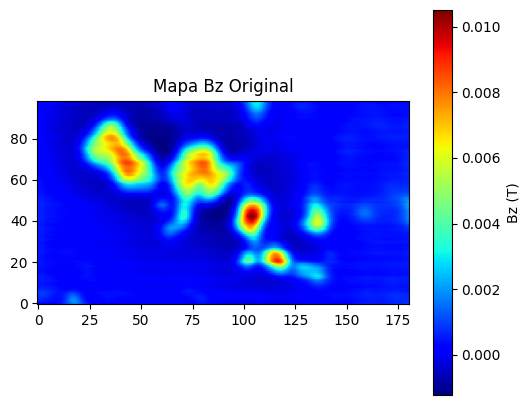

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# 1. CARREGAR O MAPA Bz
# ===========================
#bz = np.loadtxt("/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx260620241658.txt")
bz= np.loadtxt("/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx270620240930.txt")
Ny, Nx = bz.shape

print("Dimensões do mapa:", Ny, "x", Nx)

plt.figure(figsize=(6,5))
plt.imshow(bz, cmap="jet", origin="lower")
plt.colorbar(label="Bz (T)")
plt.title("Mapa Bz Original")
plt.show()

In [3]:
# ===========================
# 2. PARÂMETROS ESPACIAIS
# ===========================
dx = 40e-6   # 40 microns
dy = 40e-6

kx = 2*np.fft.fftfreq(Nx, d=dx)
ky = 2*np.fft.fftfreq(Ny, d=dy)
kx, ky = np.meshgrid(kx, ky)

k = np.sqrt(kx**2 + ky**2)   # número de onda radial

# FFT do campo
Bz_fft = np.fft.fftshift(np.fft.fftn(bz))


In [3]:
# ===========================
# 3. ESTIMAR z0 AUTOMATICAMENTE
# ===========================

bins = np.linspace(0, k.max(), 250)
radial_k = []
radial_B = []

for i in range(len(bins)-1):
    mask = (k >= bins[i]) & (k < bins[i+1])
    if np.any(mask):
        radial_k.append((bins[i]+bins[i+1])/2)
        radial_B.append(np.mean(np.abs(Bz_fft[mask])))

radial_k = np.array(radial_k)
radial_B = np.array(radial_B)

mask = (radial_k > 0) & (radial_B > 0)
k_fit = radial_k[mask]
B_fit = np.log(radial_B[mask])

coef = np.polyfit(k_fit, B_fit, 1)
inclination = coef[0]

z0_est = inclination   # distância sensor-amostra estimada

print("\nDistância estimada sensor–amostra (z0): {:.3e} m".format(z0_est))


Distância estimada sensor–amostra (z0): 1.878e-04 m


0.0001277867947829542


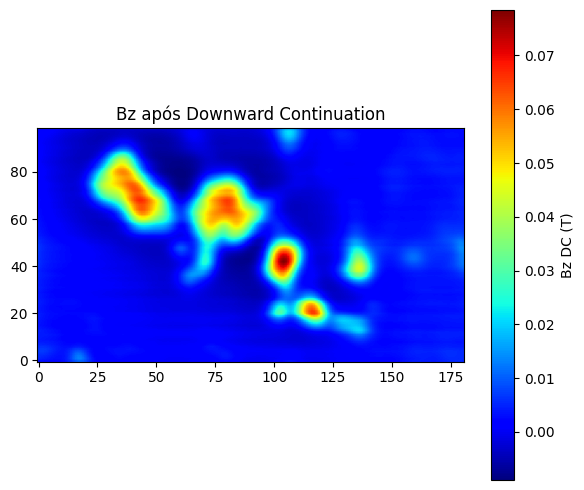

In [4]:
# ======== Escolher altura final ========
z0 = z0_est       # altura original estimada
z1 = z0 - 60e-6   # por exemplo, 60 µm mais perto
print(z1)

dz = z0 - z1      # positivo → downward continuation

# FFT do mapa original
Bz_fft_full = np.fft.fftshift(np.fft.fftn(bz))

# Fator de downward continuation: exp(k * dz)
DC_factor = np.exp(k * dz)

# Regularização para evitar explosão
alpha_dc = 1e-4
DC_reg = DC_factor / (1 + alpha_dc * DC_factor**2)

# Aplicação
Bz_dc_fft = Bz_fft_full * DC_reg
Bz_dc = np.fft.ifftn(np.fft.ifftshift(Bz_dc_fft)).real

plt.figure(figsize=(6,5))
plt.imshow(Bz_dc, cmap="jet", origin="lower")
plt.colorbar(label="Bz DC (T)")
plt.title("Bz após Downward Continuation")
plt.tight_layout()
plt.show()


treinamento CNN

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# 1. PARÂMETROS DO PROBLEMA
# ===========================
dx = 40e-6
dy = 40e-6

file_paths = [
    "/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx260620241658.txt",
    "/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx270620240930.txt",
    "/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx020720241338.txt",
    "/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx030720241005.txt",
    "/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx040720240950.txt",
]

z_um   = [200, 400, 670, 720, 900]
z_list = [z * 1e-6 for z in z_um]

# ===========================
# 2. CARREGAR MAPAS ORIGINAIS
# ===========================
raw_maps = [np.loadtxt(fp) for fp in file_paths]

Ny_ref, Nx_ref = raw_maps[0].shape
target_shape = (Ny_ref, Nx_ref)

print("Shape de referência:", target_shape)

# ===========================
# 3. FUNÇÕES AUXILIARES
# ===========================
def force_shape(bz):
    """Corte central seguro (sem tentar corrigir rotação)."""
    Ny_t, Nx_t = target_shape
    Ny, Nx = bz.shape

    if Ny < Ny_t or Nx < Nx_t:
        raise ValueError(f"Imagem menor que referência: {bz.shape}")

    y0 = (Ny - Ny_t) // 2
    x0 = (Nx - Nx_t) // 2
    return bz[y0:y0+Ny_t, x0:x0+Nx_t]


def augment_geometric(bz):
    """
    Augmentações geométricas fisicamente seguras:
    - NÃO inclui rot90 nem rot270
    """
    return [
        bz,                                # original
        np.flipud(bz),                    # flip vertical
        np.fliplr(bz),                    # flip horizontal
        np.flipud(np.fliplr(bz)),         # flip duplo
        np.rot90(bz, 2),                  # rotação 180°
    ]


def add_background_jitter(bz, amp_ratio=0.03):
    Ny, Nx = bz.shape
    x = np.linspace(-1, 1, Nx)
    y = np.linspace(-1, 1, Ny)
    X, Y = np.meshgrid(x, y)

    amp = amp_ratio * np.max(np.abs(bz))
    a, b, c = np.random.uniform(-amp, amp, size=3)
    return bz + a + b*X + c*Y


def add_noise(bz, noise_ratio=0.01):
    sigma = noise_ratio * np.std(bz)
    return bz + sigma * np.random.randn(*bz.shape)

# ===========================
# 4. DATASET FINAL (SEGURO)
# ===========================
bz_aug = []
z_aug  = []

def append_safe(bz, z):
    bz = force_shape(bz)
    bz_aug.append(bz)
    z_aug.append(z)


for bz, z in zip(raw_maps, z_list):
    for bz_g in augment_geometric(bz):

        append_safe(bz_g, z)

        if np.random.rand() < 0.5:
            append_safe(add_background_jitter(bz_g), z)

        if np.random.rand() < 0.3:
            append_safe(add_noise(bz_g), z)

# ===========================
# 5. STACK FINAL
# ===========================
bz_maps = np.stack(bz_aug)
z_list  = np.array(z_aug)

Nz, Ny, Nx = bz_maps.shape
print("Dataset FINAL:", Nz, Ny, Nx)


Shape de referência: (99, 181)
Dataset FINAL: 41 99 181


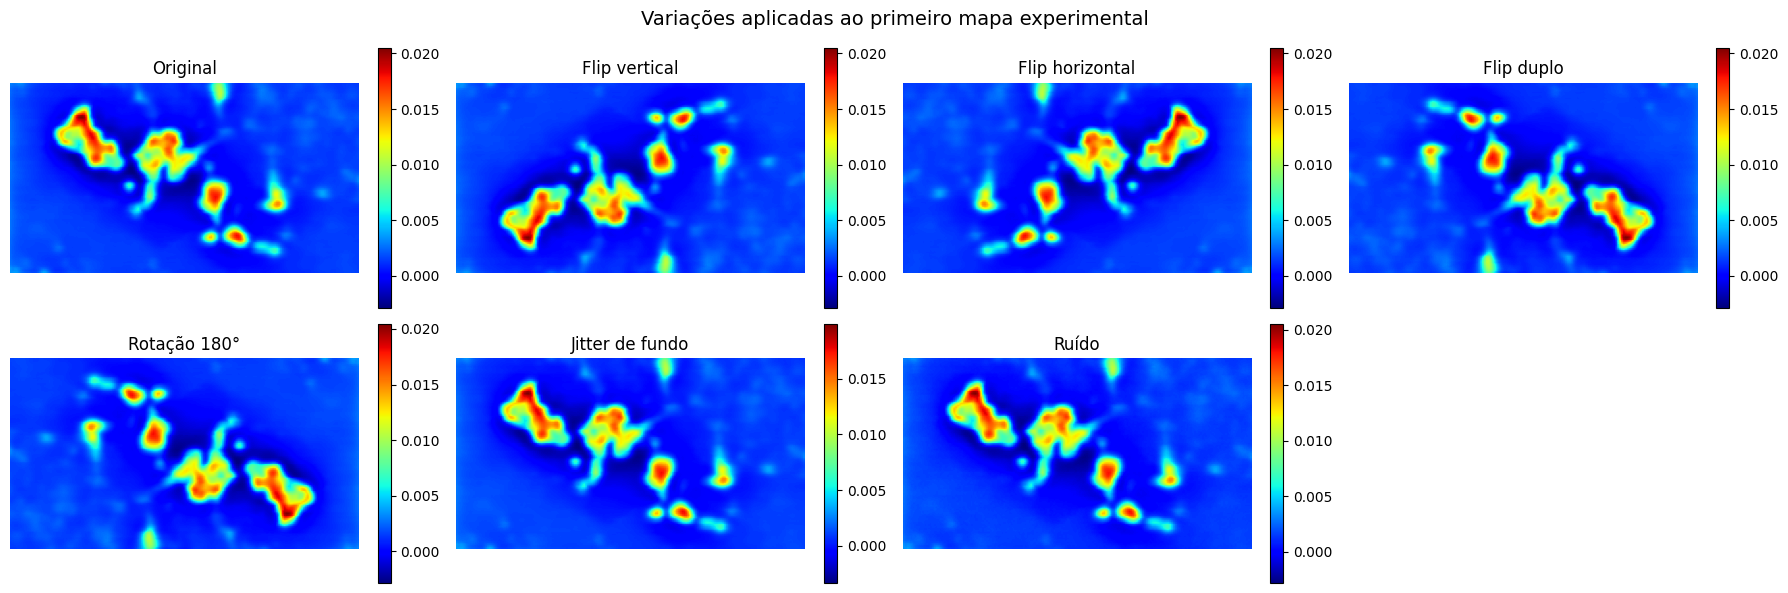

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# 1. PEGAR O PRIMEIRO MAPA
# ===========================
bz0 = raw_maps[0]

# ===========================
# 2. GERAR VARIAÇÕES
# ===========================
bz_original = bz0
bz_flip_v   = np.flipud(bz0)
bz_flip_h   = np.fliplr(bz0)
bz_flip_hv  = np.flipud(np.fliplr(bz0))
bz_rot_180  = np.rot90(bz0, 2)

bz_jitter = add_background_jitter(bz0, amp_ratio=0.03)
bz_noise  = add_noise(bz0, noise_ratio=0.01)

maps = [
    bz_original,
    bz_flip_v,
    bz_flip_h,
    bz_flip_hv,
    bz_rot_180,
    bz_jitter,
    bz_noise
]

titles = [
    "Original",
    "Flip vertical",
    "Flip horizontal",
    "Flip duplo",
    "Rotação 180°",
    "Jitter de fundo",
    "Ruído"
]

# ===========================
# 3. PLOT
# ===========================
plt.figure(figsize=(18, 6))

for i, (m, t) in enumerate(zip(maps, titles)):
    plt.subplot(2, 4, i+1)
    plt.imshow(m, cmap="jet", origin="lower")
    plt.title(t)
    plt.colorbar(fraction=0.046)
    plt.axis("off")

plt.suptitle("Variações aplicadas ao primeiro mapa experimental", fontsize=14)
plt.tight_layout()
plt.show()


In [87]:
# ===========================
# 2. FUNÇÕES PARA FFT E DC
# ===========================
def get_k_grid(Nx, Ny, dx, dy):
    """Retorna kx, ky, k em rad/m."""
    fx = np.fft.fftfreq(Nx, d=dx)
    fy = np.fft.fftfreq(Ny, d=dy)
    kx = 2*np.pi*fx
    ky = 2*np.pi*fy
    kx, ky = np.meshgrid(kx, ky)
    k = np.sqrt(kx**2 + ky**2)
    return kx, ky, k

kx, ky, k = get_k_grid(Nx, Ny, dx, dy)

def downward_continuation(bz, z_from, z_to, k, alpha_dc=1e-4):
    """
    Faz downward continuation de z_from para z_to (z_to < z_from).
    bz: mapa original (2D)
    z_from, z_to em metros
    alpha_dc: regularização
    """
    dz = z_from - z_to
    Bz_fft = np.fft.fftshift(np.fft.fftn(bz))
    DC_factor = np.exp(k * dz)
    DC_reg = DC_factor / (1 + alpha_dc * DC_factor**2)
    Bz_dc_fft = Bz_fft * DC_reg
    Bz_dc = np.fft.ifftn(np.fft.ifftshift(Bz_dc_fft)).real
    return Bz_dc

def deconvolve_footprint(bz, k, sigma_psf=80e-6, beta=1e-2):
    """
    Deconvolução do footprint gaussiano do sensor.
    sigma_psf: largura efetiva (ajuste!)
    beta: regularização
    """
    Bz_fft = np.fft.fftshift(np.fft.fftn(bz))
    PSF_k = np.exp(-0.5 * (sigma_psf**2) * (k**2))
    Bz_deconv_fft = Bz_fft / (PSF_k + beta)
    Bz_deconv = np.fft.ifftn(np.fft.ifftshift(Bz_deconv_fft)).real
    return Bz_deconv


In [88]:
# ===========================
# 3. PLANO DE REFERÊNCIA E PARES
# ===========================
# Escolher o índice do mapa mais perto (menor z)
idx_ref = int(np.argmin(z_list))
z_ref = z_list[idx_ref]
bz_ref = bz_maps[idx_ref]

print("Índice ref =", idx_ref, "| z_ref =", z_ref*1e6, "µm")

# Opcional: aplicar um filtro leve no target (p.ex. média 3x3 ou nada)
bz_ref_target = bz_ref  # por enquanto, target = mapa bruto

# Agora, para cada outro z > z_ref, trazemos para z_ref
input_maps = []
target_maps = []

for i in range(Nz):
    if i == idx_ref:
        continue  # não usar o próprio como input neste loop
    z_i = z_list[i]
    bz_i = bz_maps[i]

    # 1) Downward continuation de z_i -> z_ref
    bz_dc = downward_continuation(bz_i, z_i, z_ref, k, alpha_dc=1e-4)

    # 2) Deconvolução do footprint
    bz_dc_deconv = deconvolve_footprint(bz_dc, k, sigma_psf=80e-6, beta=1e-2)

    # 3) Normalização simples (por exemplo, dividir pelo max abs)
    scale = np.max(np.abs(bz_dc_deconv))
    if scale == 0:
        scale = 1.0
    bz_in_norm = bz_dc_deconv / scale

    # 4) Normalizar também o target com o MESMO tipo de operação global
    # (aqui podemos normalizar cada par pelo target, ou usar um único escala global)
    scale_t = np.max(np.abs(bz_ref_target))
    if scale_t == 0:
        scale_t = 1.0
    bz_t_norm = bz_ref_target / scale_t

    input_maps.append(bz_in_norm)
    target_maps.append(bz_t_norm)

input_maps = np.array(input_maps)    # shape: (N_pairs, Ny, Nx)
target_maps = np.array(target_maps)  # shape: (N_pairs, Ny, Nx)
print("N_pairs =", input_maps.shape[0])


Índice ref = 0 | z_ref = 199.99999999999997 µm
N_pairs = 40


In [103]:
# ===========================
# 4. GERAR PATCHES 2D
# ===========================
patch_size = 48   # ou 128 # isso afeta na resolucao das minhas fontes
stride = 24      # sobreposição

def extract_patches(bz_array, patch_size=48, stride=24):
    """
    bz_array: shape (N_pairs, Ny, Nx)
    Retorna lista de patches (N_patches, Ny_p, Nx_p)
    """
    patches = []
    N, Ny, Nx = bz_array.shape
    for n in range(N):
        img = bz_array[n]
        for y0 in range(0, Ny - patch_size + 1, stride):
            for x0 in range(0, Nx - patch_size + 1, stride):
                patch = img[y0:y0+patch_size, x0:x0+patch_size]
                patches.append(patch)
    return np.array(patches)

input_patches = extract_patches(input_maps, patch_size, stride)
target_patches = extract_patches(target_maps, patch_size, stride)

print("input_patches shape:", input_patches.shape)
print("target_patches shape:", target_patches.shape)
print("input_maps shape:", input_maps.shape)
print("target_maps shape:", target_maps.shape)

# pegar o tamanho da primeira imagem
print("Tamanho da imagem:", input_maps[0].shape)



input_patches shape: (720, 48, 48)
target_patches shape: (720, 48, 48)
input_maps shape: (40, 99, 181)
target_maps shape: (40, 99, 181)
Tamanho da imagem: (99, 181)


In [17]:
!pip install torch torchvision torchaudio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 MB 25.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 20.8 MB/s eta 0:00:00


In [104]:
# ===========================
# 5. DATASET E DATALOADER
# ===========================
import torch
from torch.utils.data import Dataset, DataLoader

class BzPatchDataset(Dataset):
    def __init__(self, inputs, targets):
        # inputs/targets: np.arrays (N_patches, H, W)
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        x = self.inputs[idx]   # (H, W)
        y = self.targets[idx]  # (H, W)

        # [C, H, W] com C=1
        x = x[None, ...]
        y = y[None, ...]

        x = torch.from_numpy(x).float()
        y = torch.from_numpy(y).float()
        return x, y

dataset = BzPatchDataset(input_patches, target_patches)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [105]:
# ===========================
# 6. U-NET 2D SIMPLES
# ===========================
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            #nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            #nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        self.down1 = DoubleConv(in_ch, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        bn = self.bottleneck(p3)

        u3 = self.up3(bn)
        u3 = torch.cat([u3, c3], dim=1)
        c3u = self.conv3(u3)

        u2 = self.up2(c3u)
        u2 = torch.cat([u2, c2], dim=1)
        c2u = self.conv2(u2)

        u1 = self.up1(c2u)
        u1 = torch.cat([u1, c1], dim=1)
        c1u = self.conv1(u1)

        out = self.out_conv(c1u)
        return out


In [106]:
# ===========================
# 7. TREINAMENTO
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet2D(in_ch=1, out_ch=1).to(device)

import torch.optim as optim
criterion = nn.L1Loss()  # L1 é bom para denoising
optimizer = optim.Adam(model.parameters(), lr=1e-4)

n_epochs = 600  # ajuste como quiser

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {epoch_loss:.4e}")


Epoch 1/600 - Loss: 2.1674e-01
Epoch 2/600 - Loss: 1.4708e-01
Epoch 3/600 - Loss: 1.2686e-01
Epoch 4/600 - Loss: 1.1837e-01
Epoch 5/600 - Loss: 1.1364e-01
Epoch 6/600 - Loss: 1.1066e-01
Epoch 7/600 - Loss: 1.0827e-01
Epoch 8/600 - Loss: 1.0456e-01
Epoch 9/600 - Loss: 9.5731e-02
Epoch 10/600 - Loss: 8.4401e-02
Epoch 11/600 - Loss: 7.4755e-02
Epoch 12/600 - Loss: 6.8117e-02
Epoch 13/600 - Loss: 6.1084e-02
Epoch 14/600 - Loss: 5.4442e-02
Epoch 15/600 - Loss: 4.8575e-02
Epoch 16/600 - Loss: 4.4122e-02
Epoch 17/600 - Loss: 4.0472e-02
Epoch 18/600 - Loss: 3.7429e-02
Epoch 19/600 - Loss: 3.4313e-02
Epoch 20/600 - Loss: 3.1513e-02
Epoch 21/600 - Loss: 2.9695e-02
Epoch 22/600 - Loss: 2.7999e-02
Epoch 23/600 - Loss: 2.6334e-02
Epoch 24/600 - Loss: 2.5239e-02
Epoch 25/600 - Loss: 2.4047e-02
Epoch 26/600 - Loss: 2.2640e-02
Epoch 27/600 - Loss: 2.1230e-02
Epoch 28/600 - Loss: 2.0405e-02
Epoch 29/600 - Loss: 1.9632e-02
Epoch 30/600 - Loss: 1.9057e-02
Epoch 31/600 - Loss: 1.8510e-02
Epoch 32/600 - Lo

In [107]:
# Após o loop de treinamento
save_path = "modelo_dc_cnn_sample_helder8.pth"
torch.save(model.state_dict(), save_path)
print("Modelo salvo em:", save_path)


Modelo salvo em: modelo_dc_cnn_sample_helder8.pth


In [108]:
# Carregar modelo salvo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet2D(in_ch=1, out_ch=1).to(device)
model.load_state_dict(torch.load("modelo_dc_cnn_sample_helder8.pth", map_location=device))
model.eval()

print("Modelo carregado com sucesso.")


Modelo carregado com sucesso.


/var/folders/tz/qgq86z5x6t98t9kp2w_wp39r0000gp/T/ipykernel_25999/960036884.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("modelo_dc_cn

Mapa original: (99, 181)
Tamanho após crop: (96, 176)
Modelo carregado.
Mapa salvo como Bz_180um_CNN.txt


/var/folders/tz/qgq86z5x6t98t9kp2w_wp39r0000gp/T/ipykernel_25999/2342151809.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("modelo_dc_

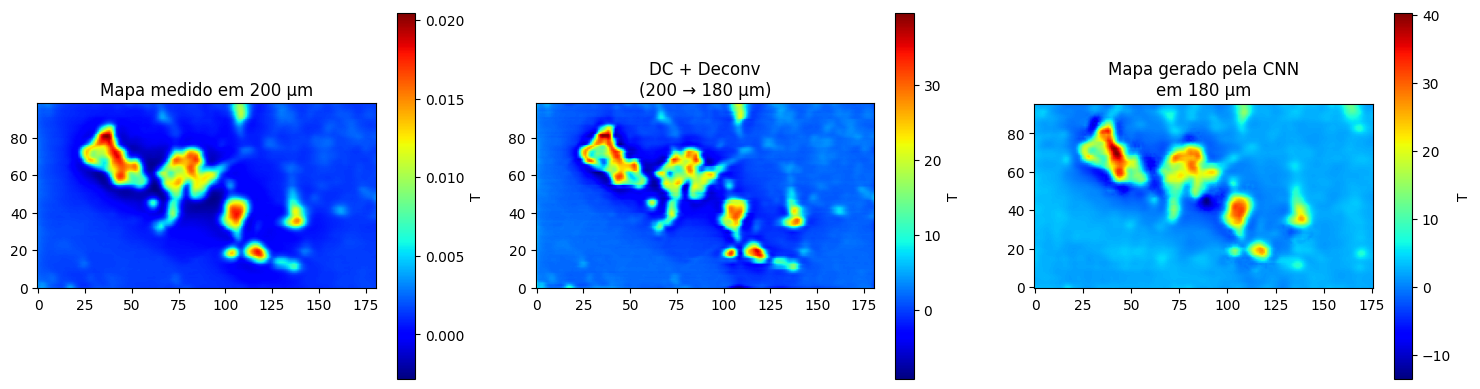

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# =====================================================
# UTILITÁRIO: cortar imagem para múltiplos de 8
# =====================================================
def crop_to_mult8(img):
    Ny, Nx = img.shape
    Ny_c = (Ny // 8) * 8
    Nx_c = (Nx // 8) * 8
    return img[:Ny_c, :Nx_c]

# =====================================================
# 1) CARREGAR O MAPA MEDIDO EM 200 µm
# =====================================================
bz_200 = np.loadtxt("/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/artigo_4d_modelagem/junction/arquivoseasimagensdosmapascomdistncia/MAPx260620241658.txt")
#bz_200=np.loadtxt("/Users/lannaisabely/Documents/laboratorio 2024/Doutorado/medidas /amostra_rocha_parnaiba/IDA/0,6A_ElderRocha_130 - IDA/MAPx180820230859.txt")
z_from = 200e-6    # altura do mapa medido
z_to   = 140e-6    # altura que você quer gerar

Ny, Nx = bz_200.shape
dx = dy = 40e-6   # ou o step real do seu mapa (CONFIRA ISSO!)

kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

k = np.sqrt(KX**2 + KY**2)

k.shape == bz_200.shape
print("Mapa original:", bz_200.shape)

# =====================================================
# 2) DOWNWARD CONTINUATION: 200 → 180 µm
# =====================================================
bz_dc = downward_continuation(
    bz_200, 
    z_from, 
    z_to, 
    k, 
    alpha_dc=1e-4
)

# =====================================================
# 3) DECONVOLUÇÃO DO FOOTPRINT
# =====================================================
bz_dc_deconv = deconvolve_footprint(
    bz_dc, 
    k, 
    sigma_psf=80e-6, 
    beta=1e-2
)

# =====================================================
# 4) CORTAR A IMAGEM PARA TAMANHOS COMPATÍVEIS COM U-NET
# =====================================================
bz_crop = crop_to_mult8(bz_dc_deconv)
Ny_c, Nx_c = bz_crop.shape
print("Tamanho após crop:", bz_crop.shape)

# =====================================================
# 5) NORMALIZAÇÃO (como no treino)
# =====================================================
scale_test = np.max(np.abs(bz_crop))
if scale_test == 0:
    scale_test = 1.0
bz_norm = bz_crop / scale_test

# =====================================================
# 6) CARREGAR O MODELO CNN
# =====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet2D(in_ch=1, out_ch=1).to(device)
model.load_state_dict(torch.load("modelo_dc_cnn_sample_helder8.pth", map_location=device))
model.eval()

print("Modelo carregado.")

# =====================================================
# 7) APLICAR CNN
# =====================================================
with torch.no_grad():
    x_t = torch.from_numpy(bz_norm[None, None, ...]).float().to(device)
    y_pred = model(x_t).cpu().numpy()[0, 0]

# =====================================================
# 8) DESNORMALIZAR → MAPA FINAL EM 180 µm
# =====================================================
Bz_180 = y_pred * scale_test

# =====================================================
# 9) SALVAR O MAPA
# =====================================================
#np.savetxt("Bz_180um_CNN.txt", Bz_180)
print("Mapa salvo como Bz_180um_CNN.txt")

# =====================================================
# 10) PLOTAR RESULTADOS
# =====================================================

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(bz_200, cmap="jet", origin='lower')
plt.colorbar(label="T")
plt.title("Mapa medido em 200 µm")

plt.subplot(1,3,2)
plt.imshow(bz_dc_deconv, cmap="jet", origin='lower')
plt.colorbar(label="T")
plt.title("DC + Deconv\n(200 → 180 µm)")

plt.subplot(1,3,3)
plt.imshow(Bz_180, cmap="jet", origin='lower')
plt.colorbar(label="T")
plt.title("Mapa gerado pela CNN\nem 180 µm")

plt.tight_layout()
plt.show()


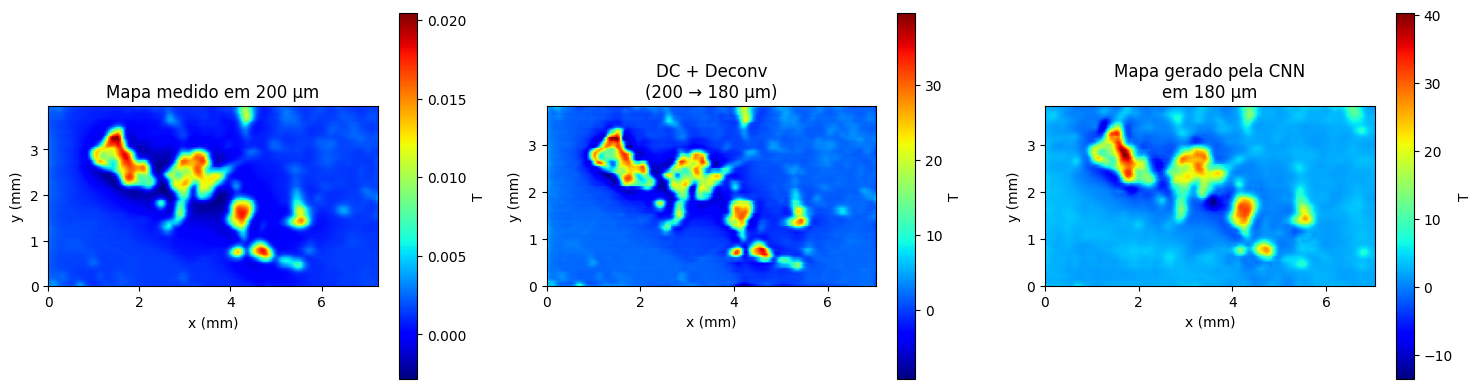

In [110]:
# =====================================================
# 10) PLOTAR RESULTADOS COM EIXOS EM mm
# =====================================================

dx = 40e-6   # PASSO EM X (m)
dy = 40e-6   # PASSO EM Y (m)

extent_crop = [0, Nx_c * dx * 1000, 0, Ny_c * dy * 1000]  # mm

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(bz_200, cmap="jet", origin='lower',
           extent=[0, bz_200.shape[1]*dx*1000,
                   0, bz_200.shape[0]*dy*1000])
plt.colorbar(label="T")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("Mapa medido em 200 µm")

plt.subplot(1,3,2)
plt.imshow(bz_dc_deconv, cmap="jet", origin='lower',
           extent=extent_crop)
plt.colorbar(label="T")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("DC + Deconv\n(200 → 180 µm)")

plt.subplot(1,3,3)
plt.imshow(Bz_180, cmap="jet", origin='lower',
           extent=extent_crop)
plt.colorbar(label="T")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("Mapa gerado pela CNN\nem 180 µm")

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Mapa gerado pela CNN\nem 180 µm')

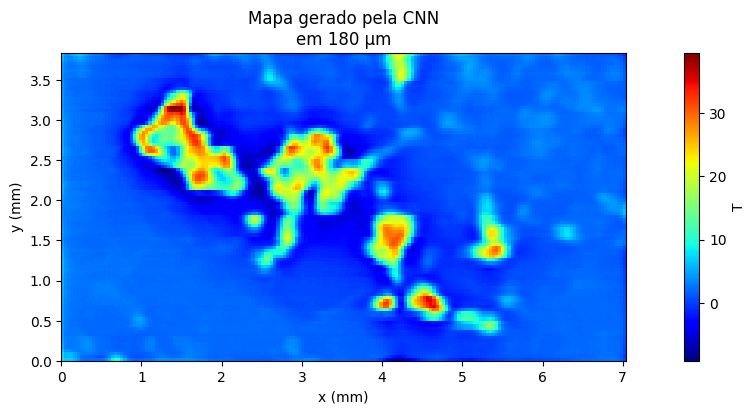

In [112]:
# Ajuste cromático consistente


plt.figure(figsize=(15,4))
plt.subplot(1,1,1)
plt.imshow((bz_dc_deconv), cmap="jet", origin='lower',
           extent=extent_crop)
plt.colorbar(label="T")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("Mapa gerado pela CNN\nem 180 µm")


Text(0.5, 1.0, 'Mapa gerado pela CNN\nem 180 µm')

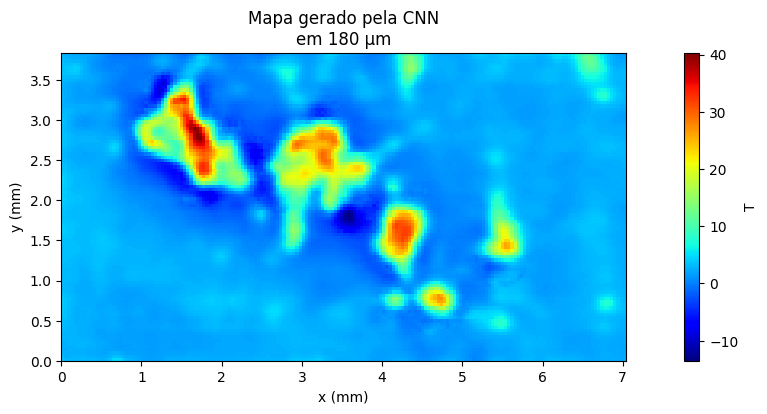

In [114]:
# Ajuste cromático consistente
vmin = np.min(Bz_180)
vmax = np.max(Bz_180)

plt.figure(figsize=(15,4))
plt.subplot(1,1,1)
plt.imshow((Bz_180), cmap="jet", origin='lower',
           extent=extent_crop, vmin=vmin, vmax=vmax)
plt.colorbar(label="T")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("Mapa gerado pela CNN\nem 180 µm")


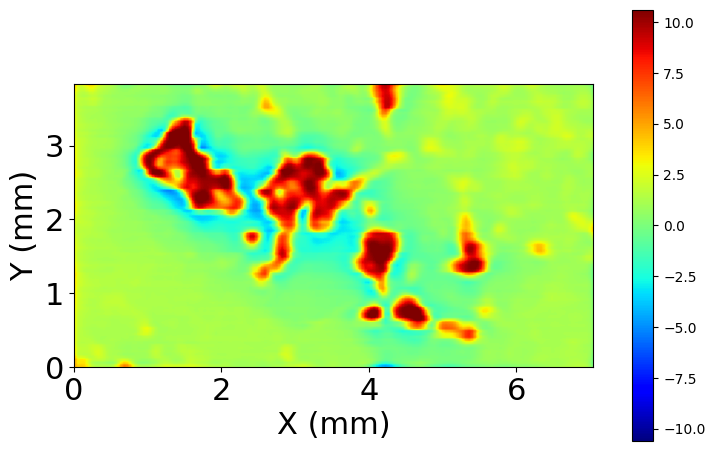

In [36]:
# Aumentar contraste com tanh (melhor solução)

Bz_180_norm = bz_dc_deconv / np.max(np.abs(bz_dc_deconv))
Bz_180_contrast = np.tanh(Bz_180_norm * 2)  # fator 2 regula o contraste

vmin = -np.max(Bz_180_contrast*11)
vmax = np.max(Bz_180_contrast*11)
# Corrigir orientação (rotacionar + flip vertical)
#Bz_plot = np.flipud(Bz_180_contrast*11)# muda a orientacao


plt.figure(figsize=(10,7))
plt.imshow(Bz_180_contrast*12, cmap="jet", origin='lower',
           extent=extent_crop, vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.28, shrink=0.8)

plt.xlabel("X (mm)",fontsize=22)
plt.ylabel("Y (mm)",fontsize=22)
plt.tick_params(axis="both", which="major", labelsize=22)  



#plt.title("Mapa gerado pela CNN (contraste melhorado)")
plt.show()


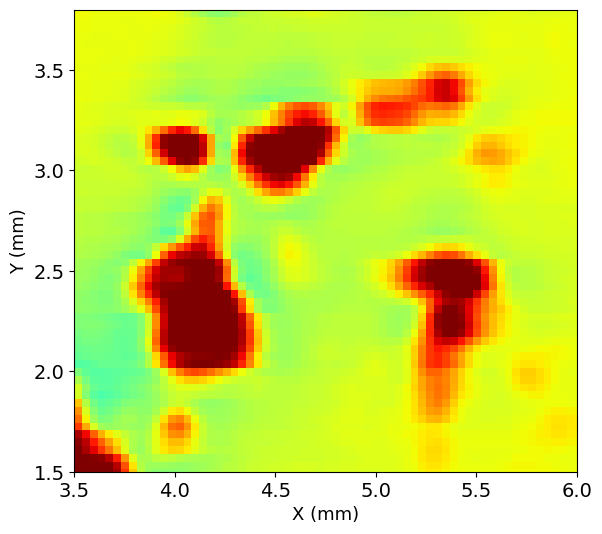

In [37]:
# Aumentar contraste com tanh (melhor solução)

Bz_180_norm = bz_dc_deconv / np.max(np.abs(bz_dc_deconv))
Bz_180_contrast = np.tanh(Bz_180_norm * 2)  # fator 2 regula o contraste

vmin = -np.max(Bz_180_contrast*11)
vmax = np.max(Bz_180_contrast*11)
# Corrigir orientação (rotacionar + flip vertical)
Bz_plot = np.flipud(Bz_180_contrast*11)# muda a orientacao


plt.figure(figsize=(7,6))
plt.imshow(Bz_plot+2, cmap="jet", origin='lower',
           extent=extent_crop, vmin=vmin, vmax=vmax)
#plt.colorbar(fraction=0.28, shrink=0.8)

plt.xlabel("X (mm)",fontsize=13)
plt.ylabel("Y (mm)",fontsize=13)
plt.tick_params(axis="both", which="major", labelsize=14)  
plt.xlim(3.5, 6)   # eixo x de 3.5 mm até 7 mm
plt.ylim(1.5, 3.8)   # eixo y de 1.5 mm até 4 mm



#plt.title("Mapa gerado pela CNN (contraste melhorado)")
plt.show()


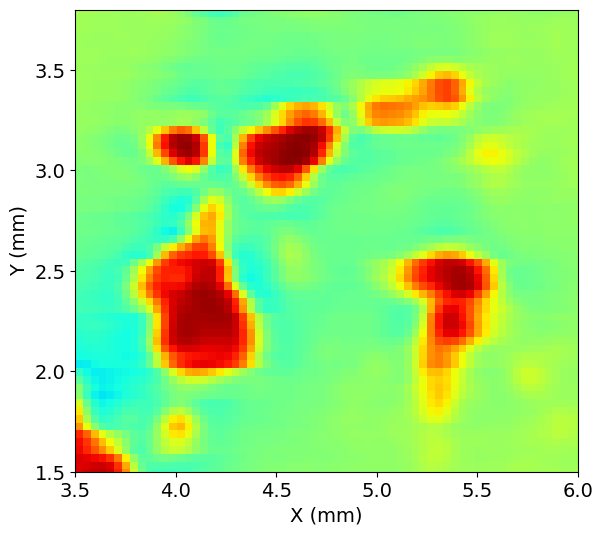

In [18]:
# Aumentar contraste com tanh (melhor solução)

Bz_180_norm = bz_dc_deconv / np.max(np.abs(bz_dc_deconv))
Bz_180_contrast = np.tanh(Bz_180_norm * 2)  # fator 2 regula o contraste

vmin = -np.max(Bz_180_contrast*11)
vmax = np.max(Bz_180_contrast*11)
# Corrigir orientação (rotacionar + flip vertical)
Bz_plot = np.flipud(Bz_180_contrast*11)# muda a orientacao


plt.figure(figsize=(7,6))
plt.imshow(Bz_plot, cmap="jet", origin='lower',
           extent=extent_crop, vmin=vmin, vmax=vmax)
#plt.colorbar(fraction=0.28, shrink=0.8)

plt.xlabel("X (mm)",fontsize=14)
plt.ylabel("Y (mm)",fontsize=14)
plt.tick_params(axis="both", which="major", labelsize=14)  
plt.xlim(3.5, 6)   # eixo x de 3.5 mm até 7 mm
plt.ylim(1.5, 3.8)   # eixo y de 1.5 mm até 4 mm


#plt.title("Mapa gerado pela CNN (contraste melhorado)")
plt.show()
